In [1]:
print("hello sangam")

hello sangam


In [2]:
!pwd

/content


In [3]:
!whoami

root


In [5]:
!cat /etc/lsb-release

DISTRIB_ID=Ubuntu
DISTRIB_RELEASE=22.04
DISTRIB_CODENAME=jammy
DISTRIB_DESCRIPTION="Ubuntu 22.04.5 LTS"


In [6]:
!free -mh

               total        used        free      shared  buff/cache   available
Mem:            12Gi       777Mi       8.9Gi       2.0Mi       3.0Gi        11Gi
Swap:             0B          0B          0B


Number of Points: 20000
Estimated Pi: 3.142
Actual Pi: 3.141592653589793
Error: 0.0004073464102067881


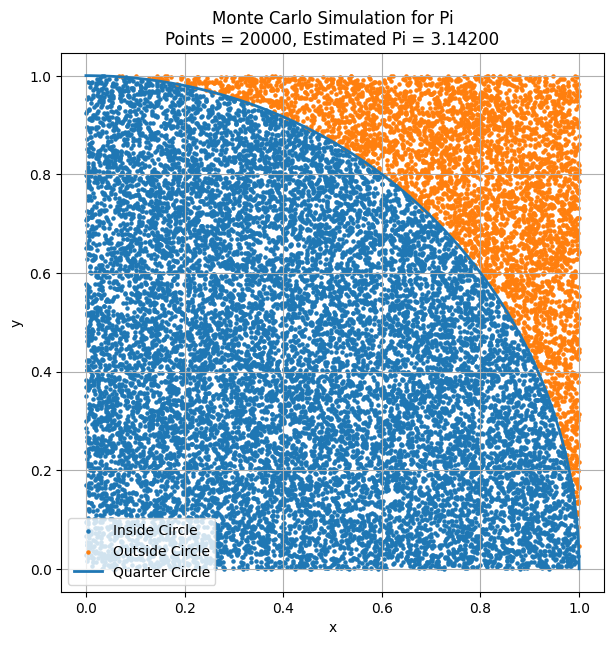


Monte Carlo Pi Estimation for Different Iterations
--------------------------------------------------
Iterations	Estimated Pi	Error
100		3.200000	0.058407
500		3.296000	0.154407
1000		3.148000	0.006407
5000		3.156000	0.014407
10000		3.145200	0.003607
50000		3.134960	0.006633
100000		3.138760	0.002833


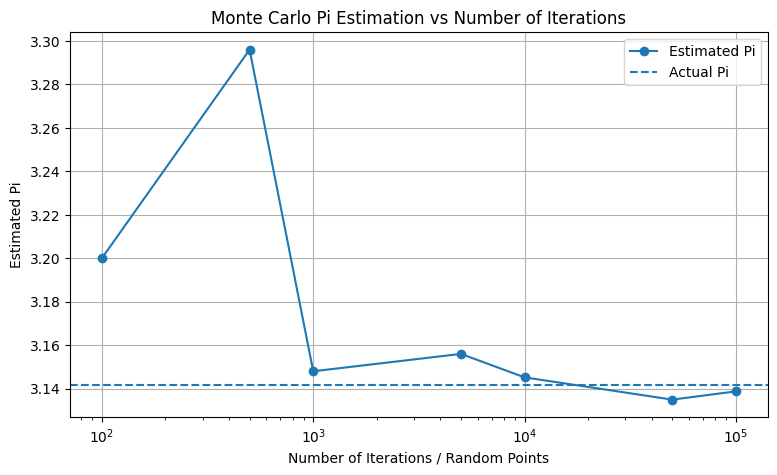

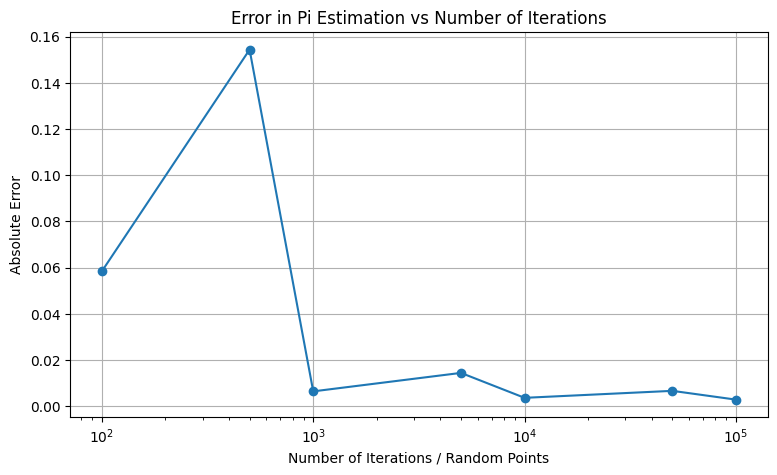

In [11]:
# ============================================================
# Monte Carlo Simulation for Estimating Pi
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Function to estimate Pi using Monte Carlo
# ------------------------------------------------------------

def monte_carlo_pi(n_points):
    """
    Estimate Pi using Monte Carlo simulation.
    n_points = number of random points
    """

    # Generate random x and y values between 0 and 1
    x = np.random.rand(n_points)
    y = np.random.rand(n_points)

    # Check whether points fall inside the quarter circle
    distance = x**2 + y**2
    inside_circle = distance <= 1

    # Count points inside circle
    n_inside = np.sum(inside_circle)

    # Estimate Pi
    pi_estimate = 4 * n_inside / n_points

    return pi_estimate, x, y, inside_circle


# ------------------------------------------------------------
# Run simulation for one selected iteration
# ------------------------------------------------------------

n_points = 20000

pi_value, x, y, inside_circle = monte_carlo_pi(n_points)

print("Number of Points:", n_points)
print("Estimated Pi:", pi_value)
print("Actual Pi:", np.pi)
print("Error:", abs(np.pi - pi_value))


# ------------------------------------------------------------
# Visualization 1: Random points inside and outside circle
# ------------------------------------------------------------

plt.figure(figsize=(7, 7))

plt.scatter(x[inside_circle], y[inside_circle], s=5, label="Inside Circle")
plt.scatter(x[~inside_circle], y[~inside_circle], s=5, label="Outside Circle")

# Draw quarter circle boundary
theta = np.linspace(0, np.pi / 2, 200)
plt.plot(np.cos(theta), np.sin(theta), linewidth=2, label="Quarter Circle")

plt.title(f"Monte Carlo Simulation for Pi\nPoints = {n_points}, Estimated Pi = {pi_value:.5f}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.axis("equal")
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# Check Pi estimation for different iterations
# ------------------------------------------------------------

iterations = [100, 500, 1000, 5000, 10000, 50000, 100000]

pi_estimates = []
errors = []

for n in iterations:
    pi_estimate, _, _, _ = monte_carlo_pi(n)
    pi_estimates.append(pi_estimate)
    errors.append(abs(np.pi - pi_estimate))

# Display result table
print("\nMonte Carlo Pi Estimation for Different Iterations")
print("--------------------------------------------------")
print("Iterations\tEstimated Pi\tError")

for n, pi_est, err in zip(iterations, pi_estimates, errors):
    print(f"{n}\t\t{pi_est:.6f}\t{err:.6f}")


# ------------------------------------------------------------
# Visualization 2: Pi estimate vs iterations
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(iterations, pi_estimates, marker="o", label="Estimated Pi")
plt.axhline(y=np.pi, linestyle="--", label="Actual Pi")

plt.xscale("log")
plt.title("Monte Carlo Pi Estimation vs Number of Iterations")
plt.xlabel("Number of Iterations / Random Points")
plt.ylabel("Estimated Pi")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# Visualization 3: Error vs iterations
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(iterations, errors, marker="o")

plt.xscale("log")
plt.title("Error in Pi Estimation vs Number of Iterations")
plt.xlabel("Number of Iterations / Random Points")
plt.ylabel("Absolute Error")
plt.grid(True)
plt.show()